In [47]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer


In [110]:
df = pd.read_csv(r"..//data/raw/ObesityDataSet.csv")
print(f'Data shape {df.shape}')
df.head()

Data shape (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [49]:
df.duplicated().sum()

np.int64(24)

In [50]:
df = df.drop_duplicates().reset_index(drop=True)
print(f'Data shape {df.shape}')
df.head()

Data shape (2087, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [51]:
df.drop('NObeyesdad',axis=1,inplace=True)

In [52]:
df.select_dtypes('number').columns

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')

In [53]:
df.select_dtypes('object').columns

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS'],
      dtype='object')

In [54]:
def add_bmi(data):
    data = data.copy()
    data['BMI'] = data['Weight'] / (data['Height']**2)
    return data

bmi_transformer = FunctionTransformer(func=add_bmi)

num_col = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE','BMI'] # + BMI
cat_col = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE','SCC', 'CALC', 'MTRANS']

scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore')

tranfor = ColumnTransformer([
        ('encoding',encoder,cat_col),
        ('scaling',scaler,num_col),
])

pipeline = Pipeline([
    ('add_bmi',bmi_transformer),
    ('col_trafor',tranfor)
])

In [60]:
df_success = pipeline.fit_transform(df)
print(f'Shape {df_success.shape}')
df_success[1]

Shape (2087, 32)


array([ 1.        ,  0.        ,  0.        ,  1.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        , -0.52661297, -1.96078827,
       -1.1785081 ,  1.08216361,  0.39090615,  1.63655215,  2.32890842,
       -1.09050525, -0.68895968])

In [115]:
column = [c.replace('encoding__','').replace('scaling__','') for c in tranfor.get_feature_names_out()]
df_s = pd.DataFrame(df_success,columns=column)
df_s.head()

,Gender_Female,Gender_Male,family_history_with_overweight_no,family_history_with_overweight_yes,FAVC_no,FAVC_yes,CAEC_Always,CAEC_Frequently,CAEC_Sometimes,CAEC_no,...,MTRANS_Walking,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,-0.526613,-0.887408,-0.872985,-0.788364,0.390906,-0.007810,-1.186977,0.554211,-0.670475
1,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,-0.526613,-1.960788,-1.178508,1.082164,0.390906,1.636552,2.328908,-1.090505,-0.688960
2,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,-0.212507,1.044677,-0.376509,-0.788364,0.390906,-0.007810,1.156947,0.554211,-0.747890
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.415705,1.044677,0.005395,1.082164,0.390906,-0.007810,1.156947,-1.090505,-0.363194
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,-0.369560,0.830001,0.112328,-0.788364,-2.225418,-0.007810,-1.186977,-1.090505,-0.177412


In [116]:
df_s.to_csv(r"../data/processed/Dataset.csv")

In [91]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=20)

nn.fit(df_success)
distances, indices = nn.kneighbors(df_success)

distances = distances[:, -1]
distances = np.sort(distances)

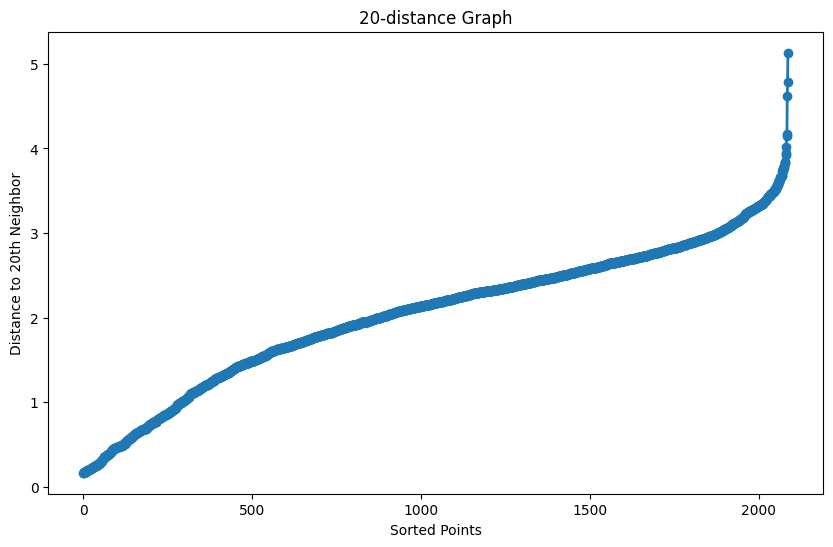

In [92]:
plt.figure(figsize=(10,6))

plt.plot(distances, lw=2,marker='o')

plt.xlabel("Sorted Points")
plt.ylabel("Distance to 20th Neighbor")
plt.title("20-distance Graph")

plt.show()

- 1 eps = 3.0
- 2 eps = 3.3
- 3 eps = 3.5